In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = (
    pd.read_csv('./data/VIC1_one_year_from_2026-02-08_16-48-23.csv')
    .loc[:, ['timestamp', 'value']]
    .rename(columns={'value':'price'})
)
df.head()

,timestamp,price
0,2026-01-08 17:00:00+10:00,138.698330
1,2026-01-08 18:00:00+10:00,143.540000
2,2026-01-08 19:00:00+10:00,119.402500
3,2026-01-08 20:00:00+10:00,99.822500
4,2026-01-08 21:00:00+10:00,92.784167


In [4]:
## wildly skewed distribution
df.describe()

,price
count,8471.000000
mean,75.507894
std,325.129509
min,-238.160830
25%,2.231250
50%,53.483333
75%,114.696665
max,14175.126000


In [ ]:
df[df.duplicated()].shape[0]<1

True

: 

: 

: 

: 

<Axes: xlabel='price', ylabel='Probability'>

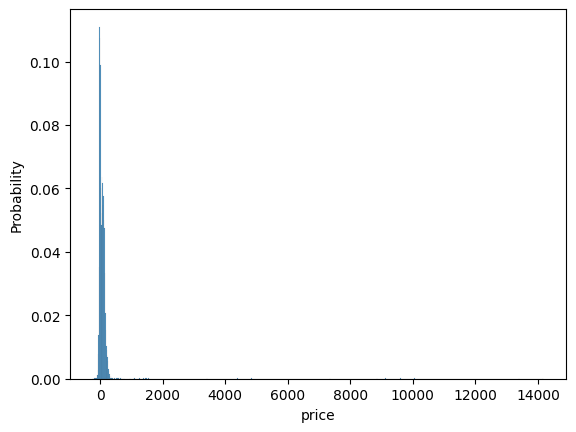

In [5]:
sns.histplot(
    data=df,
    x='price',
    stat='probability',
    bins=1000
)

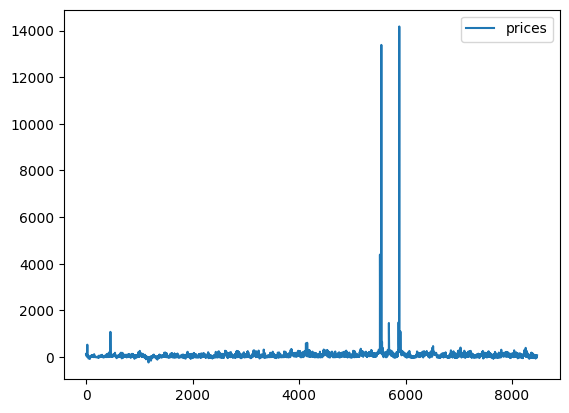

: 

: 

: 

: 

: 

In [ ]:
plt.plot(df.price, label='prices')
plt.legend()
plt.show()

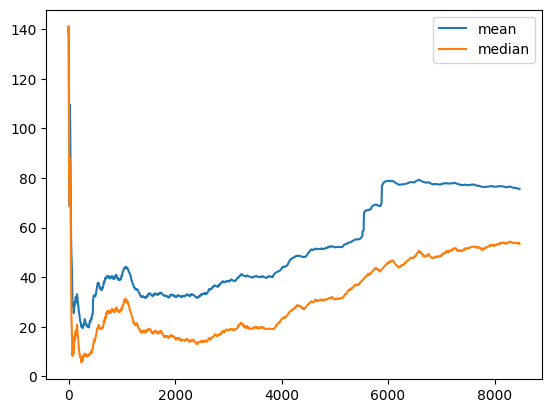

In [6]:

plt.plot(df.price.expanding().mean(), label='mean')
plt.plot(df.price.expanding().median(), label='median')
plt.legend()
plt.show();

In [7]:
from scipy import stats

mu, sigma = stats.norm.fit(df.price)
loc, scale = stats.cauchy.fit(df.price)

print(f"gaussian params: mu = {mu}; sigma = {sigma}")
print(f"cauchy params: loc: {loc}; scale: {scale}")


gaussian params: mu = 75.50789447189528; sigma = 325.1103177934903
cauchy params: loc: 44.682026652129565; scale: 48.552126808670636


In [8]:
q25, q50, q75 = df.price.quantile([0.25, 0.5, 0.75]).values
print(q50, q75-q25)

53.483333 112.465415


In [9]:
cauchy_samples = stats.cauchy.rvs(loc = loc, scale = scale, size = int(1e5), random_state=42)
cauchy_samples2 = stats.cauchy.rvs(loc=q50, scale=q75-q25, size = int(1e5), random_state=42)
normal_samples = stats.norm.rvs(loc = mu, scale=sigma, size = int(1e5), random_state=42)


In [10]:
from scipy.stats import levy_stable

def quick_fit_levy_stable(x):
    # courtesy of: https://stackoverflow.com/questions/54564850/using-scipy-to-fit-a-levy-stable-distribution#:~:text=Scipy%20estimates%20parameters%20using%20MLE,and%20convert%20the%20parameterization%20afterwards.
    # use scipy's quantile estimator to estimate the parameters and convert to S parameterization
    pconv = lambda alpha, beta, mu, sigma: (alpha, beta, mu - sigma * beta * np.tan(np.pi * alpha / 2.0), sigma)
    return pconv(*levy_stable._fitstart(x))

alpha, beta, loc, scale = quick_fit_levy_stable(df.price)

levy_samples = levy_stable.rvs(alpha = alpha, beta = beta, loc = loc, scale = scale, size = int(1e5), random_state=42)


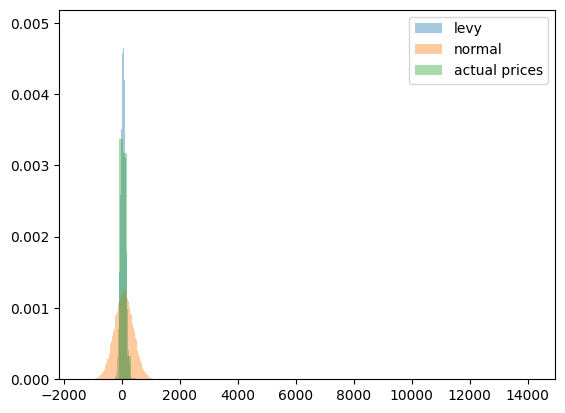

In [11]:
BINS = 100
proportion_weightings = lambda x: np.ones_like(x) / len(x)
# plt.hist(cauchy_samples, label = 'cauchy', bins = BINS, density=True, alpha = 0.4)
# plt.hist(cauchy_samples2, label = 'cauchy2', bins = BINS, density=True, alpha = 0.4)
plt.hist(levy_samples, label = 'levy', bins = BINS,density=True, alpha = 0.4)
plt.hist(normal_samples, label = 'normal', bins = BINS, density=True, alpha = 0.4)
plt.hist(df.price, label = 'actual prices', bins = BINS, density=True, alpha = 0.4)
plt.legend()
# plt.xlim(-500, 500)
plt.show()

In [12]:

## do ks test for cauchy and gaussian
## null hypothesis is that the data and cdf come from same distribution
# if p-value is less than significance level, reject null hypothesis
ks_statistic, p_value = stats.kstest(df['price'],normal_samples)
print(f"probability prices are gaussian: {p_value}")

ks_statistic, p_value = stats.kstest(df['price'], cauchy_samples)
print(f"probability prices are cauchy: {p_value}")

ks_statistic, p_value = stats.kstest(df['price'], cauchy_samples2)
print(f"probability prices are cauchy (2nd param): {p_value}")

ks_statistic, p_value = stats.kstest(df['price'], levy_samples)
print(f"probability prices are levy-alpha stable: {p_value}")

probability prices are gaussian: 0.0
probability prices are cauchy: 5.531366096429695e-148
probability prices are cauchy (2nd param): 0.0
probability prices are levy-alpha stable: 4.2557829952885407e-103


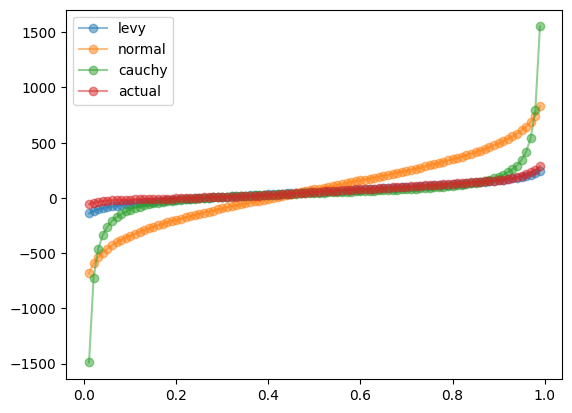

In [13]:
quantiles = [i/100 for i in range(1, 100)]
levy_q = np.quantile(levy_samples, quantiles)
cauchy_q = np.quantile(cauchy_samples, quantiles)
normal_q = np.quantile(normal_samples, quantiles)
actual_q = np.quantile(df.price, quantiles)
# print(levy_q)
# print(cauchy_q)
# print(actual_q)
plt.plot(quantiles, levy_q, label='levy', marker='o', alpha = 0.5)
plt.plot(quantiles, normal_q, label='normal', marker='o', alpha = 0.5)
plt.plot(quantiles, cauchy_q, label='cauchy', marker='o', alpha = 0.5)
plt.plot(quantiles, actual_q, label='actual', marker='o', alpha = 0.5)
plt.legend()
plt.show()

## try with price_diff

In [14]:
df['price_diff'] = df['price'].diff()

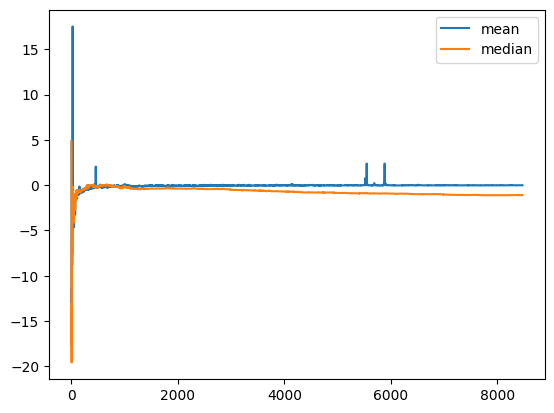

In [15]:
plt.plot(df.price_diff.expanding().mean(), label='mean')
plt.plot(df.price_diff.expanding().median(), label='median')
plt.legend()
plt.show();

## try with rolling median

<Axes: >

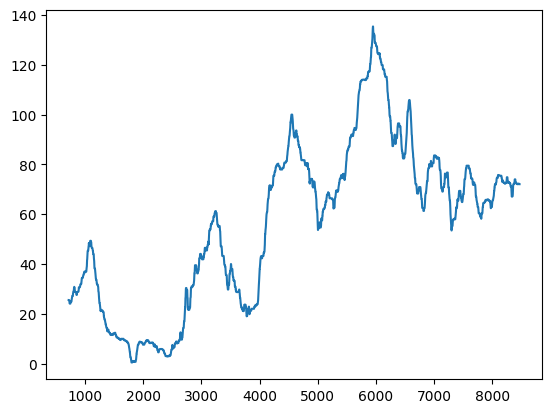

In [16]:
lag = 30*24
df['monthly_median_price'] = df['price'].rolling(window = lag).median()
df['monthly_median_price'].plot()

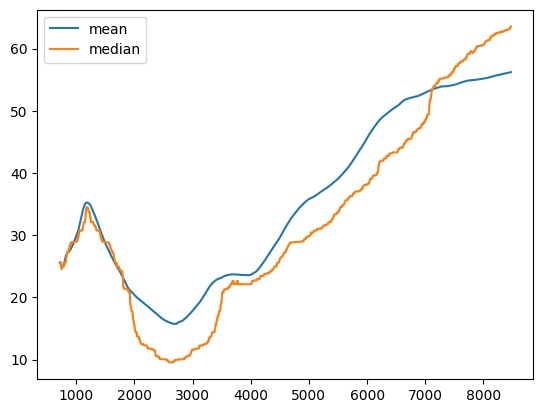

In [17]:
plt.plot(df.monthly_median_price.expanding().mean(), label='mean')
plt.plot(df.monthly_median_price.expanding().median(), label='median')
plt.legend()
plt.show();

<Axes: >

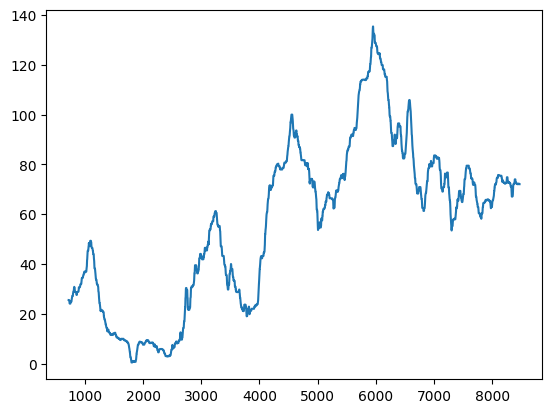

In [18]:
df['monthly_median_price'].shift(1).plot()

<Axes: >

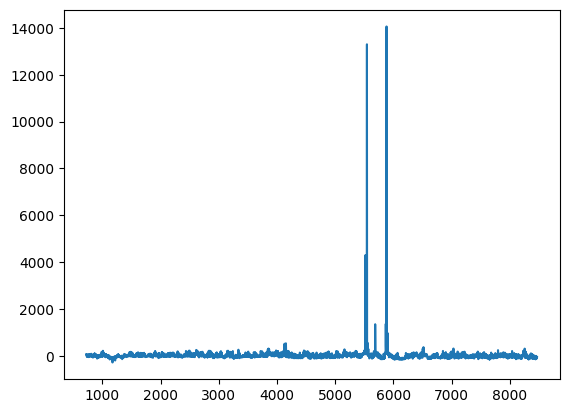

In [19]:
df['diff_from_monthly_median_price'] = (df['price'] - df['monthly_median_price']).shift(1)

df['diff_from_monthly_median_price'].plot()

In [20]:
df['diff_from_monthly_median_price']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
8466    -99.895417
8467   -100.535417
8468    -98.322917
8469    -79.521250
8470    -44.251250
Name: diff_from_monthly_median_price, Length: 8471, dtype: float64

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
modelling_data = df.loc[:,['diff_from_monthly_median_price', 'price']].dropna()
X = modelling_data['diff_from_monthly_median_price'].values
y = modelling_data['price'].values

lr.fit(X.reshape(-1, 1), y.reshape(-1, 1))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
lr.coef_, lr.intercept_

(array([[0.74821345]]), array([61.88260517]))

<Axes: >

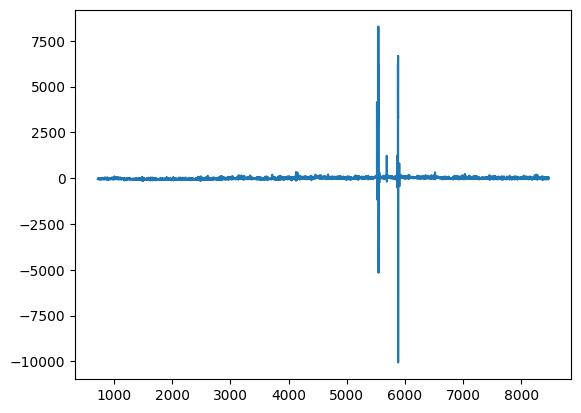

In [23]:
df.loc[~df['diff_from_monthly_median_price'].isna(),'pred'] = lr.predict(df.loc[~df['diff_from_monthly_median_price'].isna(),'diff_from_monthly_median_price'].values.reshape(-1,1))
# df[['price', 'pred']].plot()
df['errors'] = df.price - df.pred
df.errors.plot()

<Axes: >

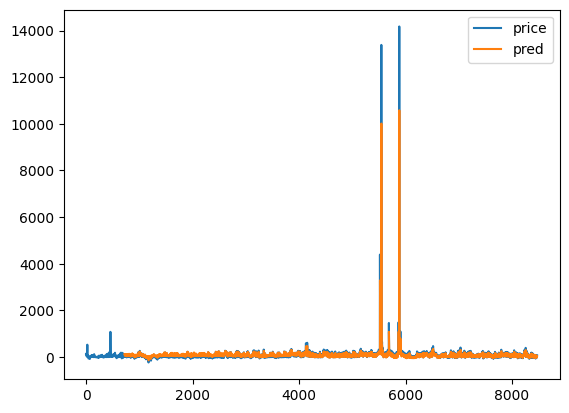

In [24]:
df[['price', 'pred']].plot()
# plt.xlim(5500, 5600)
# plt.ylim(12000, 14000)

<Axes: xlabel='price', ylabel='pred'>

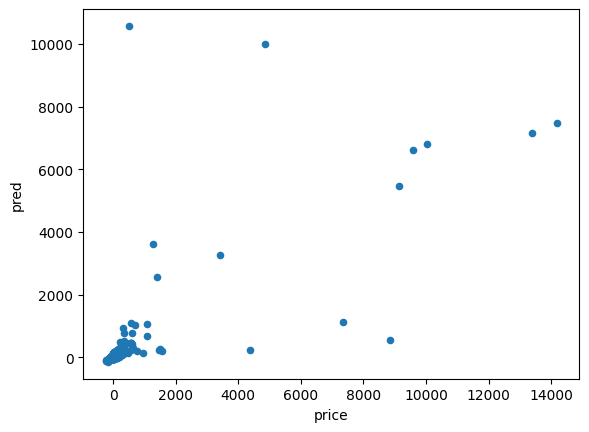

In [25]:
df.plot(x='price', y='pred', kind='scatter')

<Axes: >

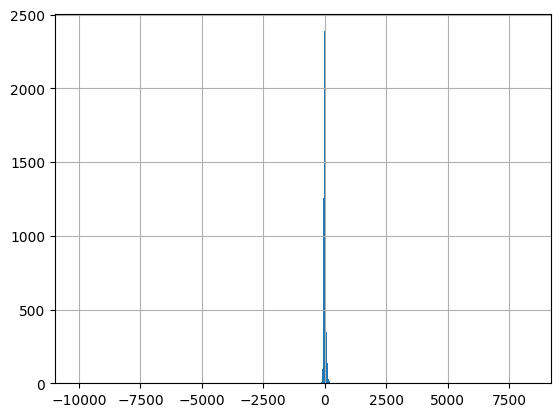

In [26]:
df['errors'].hist(bins = 500)

In [27]:
## QQ-plots for errors

mu, sigma = stats.norm.fit(df.errors.dropna())
c_loc, c_scale = stats.cauchy.fit(df.errors.dropna())
alpha, beta, l_loc, l_scale = quick_fit_levy_stable(df.errors.dropna())


print(f"gaussian params: mu = {mu}; sigma = {sigma}")
print(f"cauchy params: loc: {c_loc}; scale: {c_scale}")
print(f"levy stable params: loc: {l_loc}; scale: {l_scale}; alpha: {alpha}, beta: {beta}")

gaussian params: mu = -1.126454539674895e-14; sigma = 226.59647679069954
cauchy params: loc: -8.204741142567604; scale: 26.230367953234648
levy stable params: loc: -6.08221384354861; scale: 30.307157967040396; alpha: 1.9909127928618218, beta: 1.0


In [28]:
cauchy_samples = stats.cauchy.rvs(loc = c_loc, scale = c_scale, size = int(1e5), random_state=42)
normal_samples = stats.norm.rvs(loc = mu, scale=sigma, size = int(1e5), random_state=42)
normal_samples2 = stats.norm.rvs(loc = l_loc, scale = l_scale, size = int(1e5), random_state=42)
levy_samples = levy_stable.rvs(alpha = alpha, beta = beta, loc = l_loc, scale = l_scale, size = int(1e5), random_state=42)

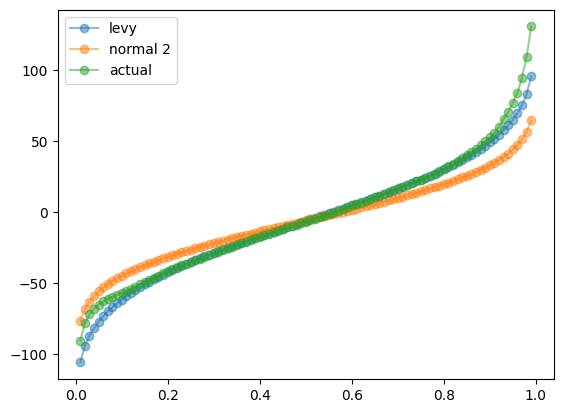

In [29]:
quantiles = [i/100 for i in range(1, 100)]
levy_q = np.quantile(levy_samples, quantiles)
cauchy_q = np.quantile(cauchy_samples, quantiles)
normal_q = np.quantile(normal_samples, quantiles)
normal_q2 = np.quantile(normal_samples2, quantiles)
actual_q = np.quantile(df.errors.dropna(), quantiles)
# print(levy_q)
# print(cauchy_q)
# print(actual_q)
plt.plot(quantiles, levy_q, label='levy', marker='o', alpha = 0.5)
# plt.plot(quantiles, normal_q, label='normal', marker='o', alpha = 0.5)
plt.plot(quantiles, normal_q2, label ='normal 2', marker='o', alpha = 0.5)
# plt.plot(quantiles, cauchy_q, label='cauchy', marker='o', alpha = 0.5)
plt.plot(quantiles, actual_q, label='actual', marker='o', alpha = 0.5)
plt.legend()
plt.show()

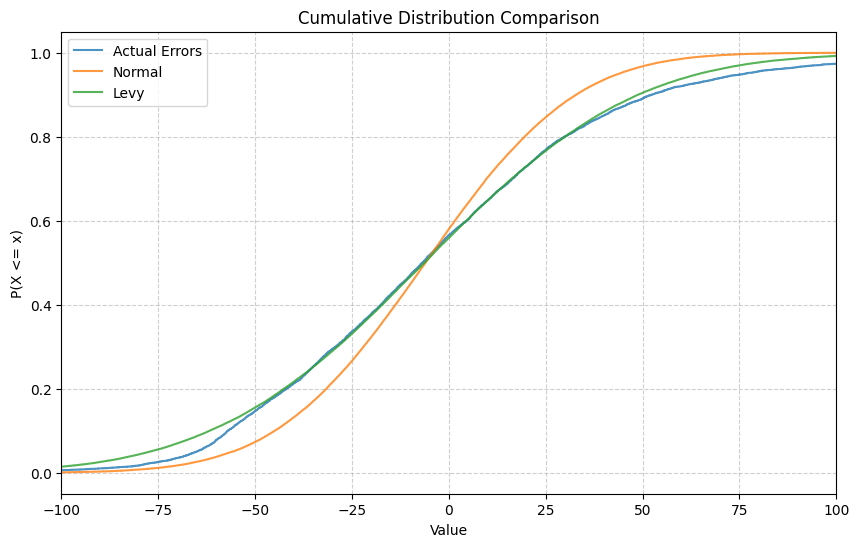

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cdfs(data_dict, title="Cumulative Distribution Comparison"):
    """
    Plots CDFs for a dictionary of data vectors.
    data_dict: {'label': vector, 'label2': vector2}
    """
    plt.figure(figsize=(10, 6))
    
    for label, data in data_dict.items():
        # Sort the data to create the x-axis
        x = np.sort(data)
        # Create the y-axis (proportions from 1/N to 1)
        y = np.arange(1, len(x) + 1) / len(x)
        
        plt.step(x, y, label=label, where='post', alpha=0.8)

    plt.title(title)
    plt.xlim(-100, 100)
    plt.xlabel('Value')
    plt.ylabel('P(X <= x)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

# How to use it with your data:
vectors = {
    'Actual Errors': df.errors.dropna(),
    'Normal': normal_samples2,
    'Levy': levy_samples,
    # 'Cauchy': cauchy_samples
}

plot_cdfs(vectors)

In [31]:
from scipy.stats import levy_stable
import numpy as np

def get_levy_quantiles(quantiles, alpha, beta, loc=0, scale=1):
    """
    Returns the values at specific quantiles for a Levy Stable distribution.
    quantiles: list or array of floats between 0 and 1 (e.g., [0.05, 0.5, 0.95])
    """
    # ppf stands for Percent Point Function (Inverse CDF)
    values = levy_stable.ppf(quantiles, alpha, beta, loc=loc, scale=scale)
    return values

# Example Usage:
# 95 pct error range
q_list = [0.025, 0.25, 0.75, 0.975]
q025, q25, q75, q975  = get_levy_quantiles(q_list, alpha=alpha, beta=beta, loc=l_loc, scale=l_scale)




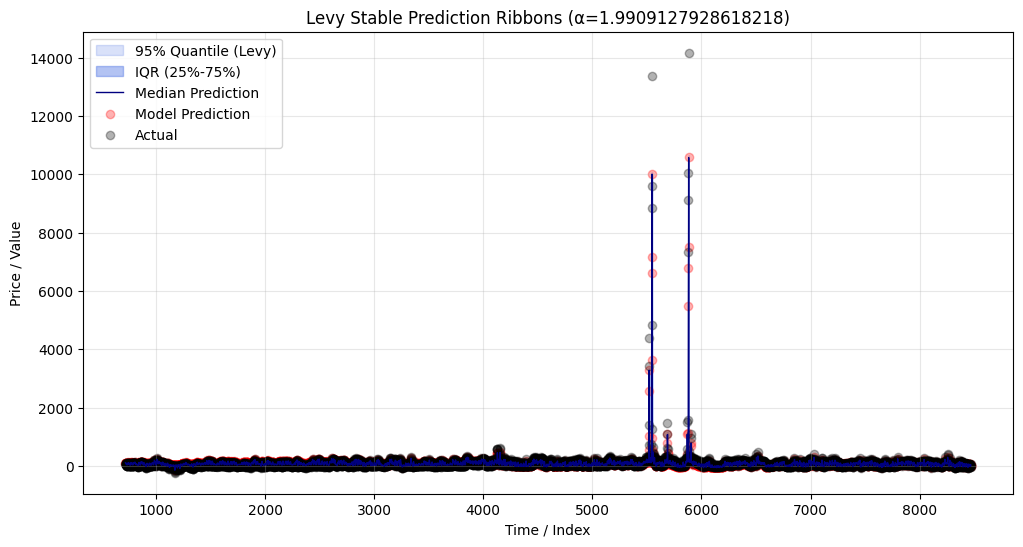

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import levy_stable

def plot_levy_ribbons(x_axis, predictions, actuals, alpha_p, beta_p, loc_p, scale_p):
    """
    Plots a prediction line with shaded Levy Stable quantile ribbons.
    """
    # 1. Define our quantile levels
    # Outer ribbon: 2.5% to 97.5% (95% CI)
    # Inner ribbon: 25% to 75% (Interquartile Range)
    q_levels = [0.025, 0.25, 0.5, 0.75, 0.975]
    
    # 2. Calculate Quantiles
    # Note: levy_stable.ppf is slow; we calculate offsets once and add to predictions
    q_offsets = levy_stable.ppf(q_levels, alpha=alpha_p, beta=beta_p, loc=loc_p, scale=scale_p)
    
    q025 = predictions + q_offsets[0]
    q25  = predictions + q_offsets[1]
    q50  = predictions + q_offsets[2] # Median
    q75  = predictions + q_offsets[3]
    q975 = predictions + q_offsets[4]

    plt.figure(figsize=(12, 6))

    # Plot the outer ribbon (Lightest)
    plt.fill_between(x_axis, q025, q975, color='royalblue', alpha=0.2, label='95% Quantile (Levy)')
    
    # Plot the inner ribbon (Darker)
    plt.fill_between(x_axis, q25, q75, color='royalblue', alpha=0.4, label='IQR (25%-75%)')
    
    # Plot the median prediction line
    plt.plot(x_axis, q50, color='navy', lw=1, label='Median Prediction')
    plt.scatter(x_axis, predictions, color = 'red', label='Model Prediction', alpha = 0.3)
    plt.scatter(x_axis, actuals, color = 'black',  label="Actual", alpha = 0.3)
    
    plt.title(f"Levy Stable Prediction Ribbons (α={alpha_p})")
    plt.xlabel("Time / Index")
    plt.ylabel("Price / Value")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

# Example Usage:
# x = df.index
# preds = df.pred
to_plot = df.dropna()
plot_levy_ribbons(to_plot.index, to_plot.pred, to_plot.price, alpha, beta, l_loc, l_scale)

In [59]:
test_df = (
    pd.read_csv('./data/VIC1_2026-02-08_18-46-09_to_2026-02-16_18-46-09.csv')
    .loc[:, ['timestamp', 'value']]
    .rename(columns={'value':'price'})
)

test_df

,timestamp,price
0,2026-02-08 19:00:00+10:00,82.040000
1,2026-02-08 20:00:00+10:00,73.105000
2,2026-02-08 21:00:00+10:00,73.873333
3,2026-02-08 22:00:00+10:00,93.048333
4,2026-02-08 23:00:00+10:00,104.840000
...,...,...
186,2026-02-16 13:00:00+10:00,37.709167
187,2026-02-16 14:00:00+10:00,77.476667
188,2026-02-16 15:00:00+10:00,105.174170
189,2026-02-16 16:00:00+10:00,162.648330


In [60]:
pd.to_datetime(test_df.timestamp)

0     2026-02-08 19:00:00+10:00
1     2026-02-08 20:00:00+10:00
2     2026-02-08 21:00:00+10:00
3     2026-02-08 22:00:00+10:00
4     2026-02-08 23:00:00+10:00
                 ...           
186   2026-02-16 13:00:00+10:00
187   2026-02-16 14:00:00+10:00
188   2026-02-16 15:00:00+10:00
189   2026-02-16 16:00:00+10:00
190   2026-02-16 17:00:00+10:00
Name: timestamp, Length: 191, dtype: datetime64[us, UTC+10:00]

In [63]:
last_train_date = df['timestamp'].max()
test_df = test_df[test_df.timestamp > last_train_date]
first_test_date = test_df['timestamp'].min()
print(last_train_date, first_test_date)

2026-02-08 15:00:00+10:00 2026-02-08 19:00:00+10:00


In [67]:
tmp_combined = pd.concat([df.assign(train=True), test_df.assign(train=False)]).sort_values('timestamp')
tmp_combined

,timestamp,price,price_diff,monthly_median_price,diff_from_monthly_median_price,pred,errors,train
8183,2025-02-09 17:00:00+10:00,-29.779167,-102.908334,73.599583,-0.470416,61.530633,-91.309800,True
8184,2025-02-09 18:00:00+10:00,-17.554167,12.225000,73.599583,-103.378750,-15.466766,-2.087401,True
8185,2025-02-09 19:00:00+10:00,4.487500,22.041667,73.108334,-91.153751,-6.319857,10.807357,True
8186,2025-02-09 20:00:00+10:00,8.099167,3.611667,73.030000,-68.620834,10.539575,-2.440408,True
8187,2025-02-09 21:00:00+10:00,-1.824167,-9.923333,73.030000,-64.930833,13.300483,-15.124649,True
...,...,...,...,...,...,...,...,...
186,2026-02-16 13:00:00+10:00,37.709167,NaN,NaN,NaN,NaN,NaN,False
187,2026-02-16 14:00:00+10:00,77.476667,NaN,NaN,NaN,NaN,NaN,False
188,2026-02-16 15:00:00+10:00,105.174170,NaN,NaN,NaN,NaN,NaN,False
189,2026-02-16 16:00:00+10:00,162.648330,NaN,NaN,NaN,NaN,NaN,False


In [68]:
tmp_combined['monthly_median_price'] = tmp_combined['price'].rolling(window = lag).median()
tmp_combined['diff_from_monthly_median_price'] = (tmp_combined['price'] - tmp_combined['monthly_median_price']).shift(1)
tmp_combined.loc[~tmp_combined.diff_from_monthly_median_price.isna(), 'pred'] = lr.predict(tmp_combined.loc[~tmp_combined.diff_from_monthly_median_price.isna(), 'diff_from_monthly_median_price'].values.reshape(-1, 1))

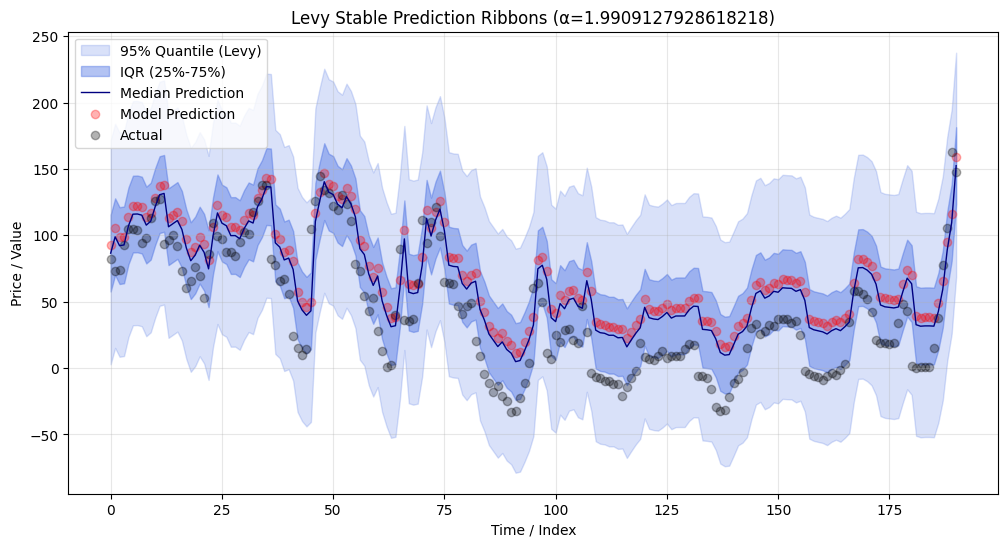

In [74]:
to_plot = tmp_combined[~tmp_combined.train]
plot_levy_ribbons(to_plot.index, to_plot.pred, to_plot.price, alpha, beta, l_loc, l_scale)

In [84]:
to_plot['in_iqr'] = ((to_plot['pred'] - np.abs(q25)) <= to_plot['price']) & (to_plot['price'] <= (to_plot['pred'] + q75))
to_plot['in_95'] = ((to_plot['pred'] - np.abs(q025)) <= to_plot['price']) & (to_plot['price'] <= (to_plot['pred'] + q975))
print(f"Percent of observations in iqr: {100 * to_plot['in_iqr'].sum()/to_plot.shape[0]:2f}%")
print(f"Percent of observations in 95 ci: {100 * to_plot['in_95'].sum()/to_plot.shape[0]:2f}%")

Percent of observations in iqr: 58.638743%
Percent of observations in 95 ci: 100.000000%


In [79]:
q25

np.float64(-35.18747253285595)

In [81]:
to_plot['q25'] = to_plot['pred'] - np.abs(q25)
to_plot['q75'] = to_plot['pred'] + np.abs(q75)
to_plot[['price', 'pred', 'q25', 'q75']]

,price,pred,q25,q75
0,82.040000,92.869137,57.681665,115.517729
1,73.105000,105.183900,69.996427,127.832491
2,73.873333,98.498612,63.311140,121.147204
3,93.048333,99.073489,63.886017,121.722081
4,104.840000,113.420482,78.233010,136.069074
...,...,...,...,...
186,37.709167,48.869926,13.682454,71.518518
187,77.476667,65.656407,30.468935,88.304999
188,105.174170,95.326811,60.139339,117.975403
189,162.648330,115.889590,80.702117,138.538181


<Axes: >

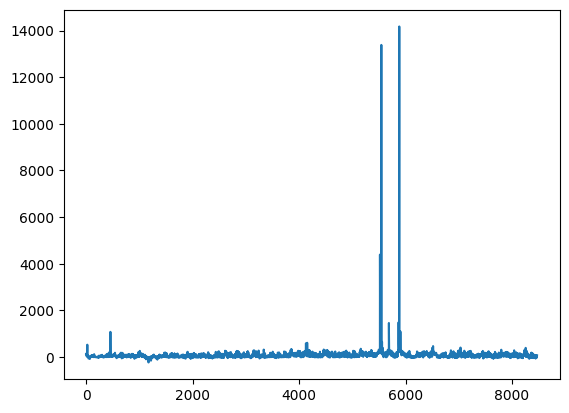

In [157]:
df['75th'] = q75
df['25th'] = q25
df['in_iqr'] = ((df['pred'] - q25) <= df['price']) & (df['price'] <= (df['pred'] + q75))

df['price'].plot()

In [ ]:
# ============================================================================
# GENERALIZED DISTRIBUTION FITTING AND VISUALIZATION
# ============================================================================

from typing import Tuple, Dict, Callable, Any
from dataclasses import dataclass

@dataclass
class DistributionParams:
    """Container for distribution parameters"""
    params: Dict[str, float]
    name: str
    
    def __repr__(self):
        param_str = "; ".join([f"{k}={v:.4f}" for k, v in self.params.items()])
        return f"{self.name} ({param_str})"

class DistributionFitter:
    """Unified interface for fitting different distributions to data"""
    
    @staticmethod
    def fit_gaussian(data: np.ndarray) -> DistributionParams:
        """Fit Gaussian (Normal) distribution"""
        mu, sigma = stats.norm.fit(data)
        return DistributionParams(
            params={'mu': mu, 'sigma': sigma},
            name='Gaussian'
        )
    
    @staticmethod
    def fit_cauchy(data: np.ndarray) -> DistributionParams:
        """Fit Cauchy distribution"""
        loc, scale = stats.cauchy.fit(data)
        return DistributionParams(
            params={'loc': loc, 'scale': scale},
            name='Cauchy'
        )
    
    @staticmethod
    def fit_levy_stable(data: np.ndarray) -> DistributionParams:
        """Fit Levy Stable distribution using quantile estimation"""
        # Convert to S parameterization
        pconv = lambda alpha, beta, mu, sigma: (
            alpha, beta, 
            mu - sigma * beta * np.tan(np.pi * alpha / 2.0), 
            sigma
        )
        alpha, beta, loc, scale = pconv(*levy_stable._fitstart(data))
        return DistributionParams(
            params={'alpha': alpha, 'beta': beta, 'loc': loc, 'scale': scale},
            name='Levy Stable'
        )
    
    @staticmethod
    def fit(data: np.ndarray, distribution: str) -> DistributionParams:
        """Fit specified distribution to data"""
        data_clean = np.asarray(data)
        data_clean = data_clean[~np.isnan(data_clean)]
        
        if distribution.lower() == 'gaussian':
            return DistributionFitter.fit_gaussian(data_clean)
        elif distribution.lower() == 'cauchy':
            return DistributionFitter.fit_cauchy(data_clean)
        elif distribution.lower() == 'levy' or distribution.lower() == 'levy_stable':
            return DistributionFitter.fit_levy_stable(data_clean)
        else:
            raise ValueError(f"Unknown distribution: {distribution}")

class DistributionSampler:
    """Generate samples from fitted distributions"""
    
    DISTRIBUTIONS = {
        'gaussian': stats.norm,
        'cauchy': stats.cauchy,
        'levy': levy_stable,
        'levy_stable': levy_stable,
    }
    
    @staticmethod
    def sample(dist_params: DistributionParams, size: int = int(1e5), 
               random_state: int = 42) -> np.ndarray:
        """Generate samples from a fitted distribution"""
        dist_name = dist_params.name.lower().replace(' ', '_')
        
        if 'gaussian' in dist_name:
            return stats.norm.rvs(
                loc=dist_params.params['mu'],
                scale=dist_params.params['sigma'],
                size=size,
                random_state=random_state
            )
        elif 'cauchy' in dist_name:
            return stats.cauchy.rvs(
                loc=dist_params.params['loc'],
                scale=dist_params.params['scale'],
                size=size,
                random_state=random_state
            )
        elif 'levy' in dist_name:
            return levy_stable.rvs(
                alpha=dist_params.params['alpha'],
                beta=dist_params.params['beta'],
                loc=dist_params.params['loc'],
                scale=dist_params.params['scale'],
                size=size,
                random_state=random_state
            )
        else:
            raise ValueError(f"Cannot sample from: {dist_params.name}")

class DistributionQuantiles:
    """Get quantiles from fitted distributions"""
    
    @staticmethod
    def get_quantiles(dist_params: DistributionParams, quantiles: list) -> np.ndarray:
        """Get quantile values for a fitted distribution"""
        quantiles = np.asarray(quantiles)
        dist_name = dist_params.name.lower().replace(' ', '_')
        
        if 'gaussian' in dist_name:
            return stats.norm.ppf(
                quantiles,
                loc=dist_params.params['mu'],
                scale=dist_params.params['sigma']
            )
        elif 'cauchy' in dist_name:
            return stats.cauchy.ppf(
                quantiles,
                loc=dist_params.params['loc'],
                scale=dist_params.params['scale']
            )
        elif 'levy' in dist_name:
            return levy_stable.ppf(
                quantiles,
                alpha=dist_params.params['alpha'],
                beta=dist_params.params['beta'],
                loc=dist_params.params['loc'],
                scale=dist_params.params['scale']
            )
        else:
            raise ValueError(f"Cannot get quantiles from: {dist_params.name}")

def plot_distribution_comparison(data_dict: Dict[str, np.ndarray], 
                                  title: str = "Distribution Comparison",
                                  xlim: Tuple[float, float] = None):
    """
    Compare CDFs of multiple distributions
    
    data_dict: {'label': data_array, ...}
    """
    plt.figure(figsize=(10, 6))
    
    for label, data in data_dict.items():
        data_clean = data[~np.isnan(data)]
        x = np.sort(data_clean)
        y = np.arange(1, len(x) + 1) / len(x)
        plt.step(x, y, label=label, where='post', alpha=0.8)
    
    plt.title(title)
    if xlim:
        plt.xlim(xlim)
    plt.xlabel('Value')
    plt.ylabel('P(X ≤ x)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

def plot_quantile_qq(dist_params: DistributionParams, data: np.ndarray,
                      title: str = None):
    """
    Plot quantile-quantile comparison between fitted distribution and data
    """
    data_clean = data[~np.isnan(data)]
    quantiles = np.linspace(0.01, 0.99, 100)
    
    theoretical_q = DistributionQuantiles.get_quantiles(dist_params, quantiles)
    empirical_q = np.quantile(data_clean, quantiles)
    
    plt.figure(figsize=(8, 8))
    plt.plot(theoretical_q, empirical_q, 'o', alpha=0.6, label='Data vs Fit')
    
    # Add diagonal reference line
    min_val = min(theoretical_q.min(), empirical_q.min())
    max_val = max(theoretical_q.max(), empirical_q.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Fit')
    
    plt.xlabel(f'{dist_params.name} Theoretical Quantiles')
    plt.ylabel('Empirical Quantiles')
    plt.title(title or f'Q-Q Plot: {dist_params.name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

def plot_prediction_ribbons(x_axis: np.ndarray, predictions: np.ndarray, 
                            actuals: np.ndarray, dist_params: DistributionParams,
                            quantile_levels: list = [0.025, 0.25, 0.75, 0.975],
                            title: str = None):
    """
    Plot predictions with uncertainty ribbons based on fitted error distribution
    
    quantile_levels: which quantiles to use as ribbon boundaries
    """
    q_offsets = DistributionQuantiles.get_quantiles(dist_params, quantile_levels)
    
    q_lower_outer = predictions + q_offsets[0]
    q_lower_inner = predictions + q_offsets[1]
    q_median = predictions + 0  # Median of error distribution
    q_upper_inner = predictions + q_offsets[2]
    q_upper_outer = predictions + q_offsets[3]
    
    plt.figure(figsize=(12, 6))
    
    # Outer ribbon (95% CI)
    plt.fill_between(x_axis, q_lower_outer, q_upper_outer, 
                     color='royalblue', alpha=0.2, label='95% Range')
    
    # Inner ribbon (IQR)
    plt.fill_between(x_axis, q_lower_inner, q_upper_inner, 
                     color='royalblue', alpha=0.4, label='IQR (25%-75%)')
    
    # Point estimates
    plt.scatter(x_axis, predictions, color='red', label='Prediction', alpha=0.3, s=20)
    plt.scatter(x_axis, actuals, color='black', label='Actual', alpha=0.3, s=20)
    
    plt.title(title or f"Prediction Ribbons ({dist_params.name} Errors)")
    plt.xlabel("Time / Index")
    plt.ylabel("Value")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage
print("Distribution fitting utilities loaded successfully!")

In [ ]:
# ============================================================================
# EXAMPLE: Using the Generalized Distribution Framework
# ============================================================================

# Extract clean error data
error_data = df.errors.dropna().values

# Fit all three distributions
fitter = DistributionFitter()
dist_gaussian = fitter.fit(error_data, 'gaussian')
dist_cauchy = fitter.fit(error_data, 'cauchy')
dist_levy = fitter.fit(error_data, 'levy')

print("Fitted Distribution Parameters:")
print(f"  {dist_gaussian}")
print(f"  {dist_cauchy}")
print(f"  {dist_levy}")
print()

# Sample from each distribution
sampler = DistributionSampler()
samples_gaussian = sampler.sample(dist_gaussian)
samples_cauchy = sampler.sample(dist_cauchy)
samples_levy = sampler.sample(dist_levy)

# Compare distributions via CDF
print("Plotting CDF comparison...")
plot_distribution_comparison({
    'Actual Errors': error_data,
    'Gaussian': samples_gaussian,
    'Cauchy': samples_cauchy,
    'Levy Stable': samples_levy
})


In [ ]:
# ============================================================================
# Q-Q PLOTS: Compare each distribution's fit to the data
# ============================================================================

# You can now easily compare different distributions using Q-Q plots
print("Gaussian Q-Q Plot:")
plot_quantile_qq(dist_gaussian, error_data, title="Error Distribution vs Gaussian")

print("\nCauchy Q-Q Plot:")
plot_quantile_qq(dist_cauchy, error_data, title="Error Distribution vs Cauchy")

print("\nLevy Stable Q-Q Plot:")
plot_quantile_qq(dist_levy, error_data, title="Error Distribution vs Levy Stable")


In [ ]:
# ============================================================================
# PREDICTION RIBBONS: Use different distributions for uncertainty
# ============================================================================

# Prepare test data
to_plot = tmp_combined[~tmp_combined.train].reset_index(drop=True)
x_idx = np.arange(len(to_plot))

# Plot predictions with uncertainty using each distribution
print("Predictions with Gaussian error model:")
plot_prediction_ribbons(x_idx, to_plot.pred.values, to_plot.price.values, 
                        dist_gaussian)

print("\nPredictions with Cauchy error model:")
plot_prediction_ribbons(x_idx, to_plot.pred.values, to_plot.price.values, 
                        dist_cauchy)

print("\nPredictions with Levy Stable error model:")
plot_prediction_ribbons(x_idx, to_plot.pred.values, to_plot.price.values, 
                        dist_levy)


In [ ]:
# ============================================================================
# COVERAGE STATISTICS: Evaluate prediction interval performance
# ============================================================================

# Calculate what percentage of actual values fall within predicted intervals
print("Coverage statistics for different error distributions:\n")

coverage_gaussian = get_coverage_statistics(to_plot.pred.values, to_plot.price.values, dist_gaussian)
coverage_cauchy = get_coverage_statistics(to_plot.pred.values, to_plot.price.values, dist_cauchy)
coverage_levy = get_coverage_statistics(to_plot.pred.values, to_plot.price.values, dist_levy)

for stat in [coverage_gaussian, coverage_cauchy, coverage_levy]:
    print(f"{stat['distribution']:15s} - IQR coverage: {stat['iqr_coverage']:.2%}  |  95% CI: {stat['ci_95_coverage']:.2%}")


In [ ]:
# ============================================================================
# How to use the distribution_fitting module in other scripts/notebooks
# ============================================================================

# After running the above, you can import from the utility module:
# 
# from distribution_fitting import (
#     DistributionFitter,
#     DistributionSampler,
#     DistributionQuantiles,
#     plot_distribution_comparison,
#     plot_quantile_qq,
#     plot_prediction_ribbons,
#     get_coverage_statistics
# )
# 
# # Fit a distribution
# fitter = DistributionFitter()
# dist = fitter.fit(error_data, 'levy')  # or 'gaussian', 'cauchy'
# 
# # Sample from it
# sampler = DistributionSampler()
# samples = sampler.sample(dist)
# 
# # Get specific quantiles for prediction intervals
# q = DistributionQuantiles.get_quantiles(dist, [0.025, 0.975])
# lower_bound = predictions + q[0]
# upper_bound = predictions + q[1]
# 
# # Compare distributions visually
# plot_quantile_qq(dist, data)
# 
# # Plot predictions with ribbons
# plot_prediction_ribbons(x_axis, predictions, actuals, dist)

print("✓ Generalized distribution fitting framework ready to use!")